# DRE

Direction des ressources en eau

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
from src.datasources import dre

In [20]:
df = dre.open_dre_obsv()

In [21]:
df.dtypes

Date        datetime64[ns]
level_cm           float64
dtype: object

<Axes: xlabel='Date'>

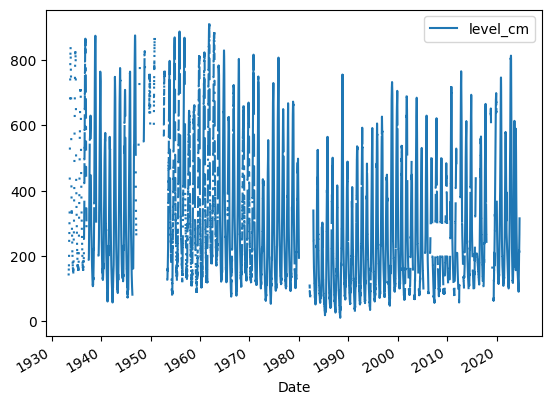

In [23]:
df.set_index("Date").plot()

In [35]:
MIN_YEAR = 2003
MAX_YEAR = 2022

In [40]:
peaks = df.loc[
    df[(df["Date"].dt.year >= MIN_YEAR) & (df["Date"].dt.year <= MAX_YEAR)]
    .groupby(df["Date"].dt.year)["level_cm"]
    .idxmax()
]
peaks["year"] = peaks["Date"].dt.year
peaks["rank"] = peaks["level_cm"].rank(ascending=False)
peaks["rp"] = len(peaks) / peaks["rank"]
peaks = peaks.sort_values("rank")

In [41]:
peaks

,Date,level_cm,year,rank,rp
49344,2022-11-13 07:00:00,814.0,2022,1.0,20.000000
43663,2012-10-18 07:00:00,766.0,2012,2.0,10.000000
48739,2020-11-02 07:00:00,747.0,2020,3.0,6.666667
42475,2010-10-26 07:00:00,717.0,2010,4.0,5.000000
48356,2019-11-15 00:00:00,699.0,2019,5.0,4.000000
45049,2014-10-30 07:00:00,694.0,2014,6.0,3.333333
36639,2003-10-23 07:00:00,685.0,2003,7.0,2.857143
47097,2017-09-23 00:00:00,666.0,2017,8.0,2.500000
47595,2018-10-18 00:00:00,652.0,2018,9.0,2.222222
38466,2005-10-21 07:00:00,630.0,2005,10.0,2.000000
